# Previsão do Valor de Recompra de Clientes em E-commerce
### Regressão Linear Múltipla vs. Regressão Ridge no Dataset UCI Online Retail

**Equipe:** Thiago, Vinicius Fabris, Murilo Cambruzzi
**Disciplina:** Machine Learning
**Dataset:** [UCI Online Retail](https://archive.ics.uci.edu/dataset/352/online+retail)

Este notebook implementa o pipeline completo do projeto: carregamento dos dados, EDA, pré-processamento, engenharia de atributos (RFM), treinamento e comparação de dois modelos de regressão, e avaliação final.

## 1. Imports

In [1]:
import urllib.request
import zipfile
import io

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor

RANDOM_STATE = 42
plt.style.use('seaborn-v0_8-whitegrid')

## 2. Carregamento dos Dados

O dataset é baixado diretamente do repositório da UCI (formato `.xlsx`, ~24 MB).

In [2]:
url = "https://archive.ics.uci.edu/static/public/352/online+retail.zip"
resp = urllib.request.urlopen(url, timeout=60)
with zipfile.ZipFile(io.BytesIO(resp.read())) as z:
    with z.open("Online Retail.xlsx") as f:
        df = pd.read_excel(f)

df.shape

(541909, 8)

## 3. Análise Exploratória de Dados (EDA)

Base transacional: cada linha é um item comprado em uma nota fiscal (`InvoiceNo`), não um cliente. Antes de qualquer modelagem é preciso entender volume, tipos, ausentes e valores inválidos.

In [3]:
df.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object

In [4]:
df.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [5]:
print("Linhas sem CustomerID:", df['CustomerID'].isna().sum())
print("Quantity negativa (devoluções/cancelamentos):", (df['Quantity'] < 0).sum())
print("UnitPrice <= 0 (lançamentos inválidos):", (df['UnitPrice'] <= 0).sum())
print("Invoices de cancelamento (prefixo C):", df['InvoiceNo'].astype(str).str.startswith('C').sum())
print("Período:", df['InvoiceDate'].min(), "→", df['InvoiceDate'].max())
print("Países distintos:", df['Country'].nunique())

Linhas sem CustomerID: 135080
Quantity negativa (devoluções/cancelamentos): 10624
UnitPrice <= 0 (lançamentos inválidos): 2517
Invoices de cancelamento (prefixo C): 9288
Período: 2010-12-01 08:26:00 → 2011-12-09 12:50:00
Países distintos: 38


Códigos de produto que na verdade são ajustes administrativos (frete, taxas, descontos, amostras) e não vendas reais:

In [6]:
NON_PRODUCT_CODES = {'POST', 'DOT', 'M', 'C2', 'D', 'S', 'BANK CHARGES', 'AMAZONFEE', 'CRUK', 'PADS', 'B'}
df['StockCode'].astype(str).value_counts().loc[lambda s: s.index.isin(NON_PRODUCT_CODES)]

StockCode
POST            1256
DOT              710
M                571
C2               144
D                 77
S                 63
BANK CHARGES      37
AMAZONFEE         34
CRUK              16
PADS               4
B                  3
Name: count, dtype: int64

## 4. Pré-processamento: Higiene Mínima e Checagem de Esquema

O pipeline segue a ordem vista em aula: limpeza determinística **antes** de qualquer estatística, sem imputar nem remover outlier nesta fase.

1. Remove linhas sem `CustomerID` (a linha não pode ser atribuída a nenhum cliente).
2. Remove linhas com `UnitPrice <= 0` (lançamento inválido, fora de faixa válida na checagem de esquema).
3. Remove códigos de produto que não representam venda real (frete, taxas, descontos, amostras).

O pipeline mantém devoluções com `Quantity` negativa: elas representam comportamento real do cliente e reduzem corretamente o valor monetário líquido.

In [7]:
n_raw = len(df)

df_clean = df.dropna(subset=['CustomerID']).copy()
n_after_customerid = len(df_clean)

df_clean = df_clean[df_clean['UnitPrice'] > 0].copy()
n_after_price = len(df_clean)

df_clean = df_clean[~df_clean['StockCode'].astype(str).isin(NON_PRODUCT_CODES)].copy()
n_after_codes = len(df_clean)

df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']

print(f"Linhas: {n_raw} → {n_after_customerid} (sem CustomerID) → {n_after_price} (preço válido) → {n_after_codes} (sem códigos não-produto)")

Linhas: 541909 → 406829 (sem CustomerID) → 406789 (preço válido) → 404876 (sem códigos não-produto)


## 5. Split Temporal e Engenharia de Atributos (RFM)

**Regra de ouro contra data leakage**: para prever o valor futuro de recompra, as features (RFM) usam só transações de uma **janela histórica**, e o alvo (target) vem só de transações de uma **janela futura**, sem sobreposição. O corte fica em 75% da linha do tempo do dataset (cerca de 9 meses de histórico, 3 meses de futuro).

In [8]:
min_date = df_clean['InvoiceDate'].min()
max_date = df_clean['InvoiceDate'].max()
total_days = (max_date - min_date).days
cutoff = min_date + pd.Timedelta(days=int(total_days * 0.75))

hist = df_clean[df_clean['InvoiceDate'] <= cutoff].copy()
future = df_clean[df_clean['InvoiceDate'] > cutoff].copy()
ref_date = cutoff

print("Janela histórica:", min_date.date(), "→", cutoff.date(), f"({len(hist)} transações)")
print("Janela futura:   ", cutoff.date(), "→", max_date.date(), f"({len(future)} transações)")

Janela histórica: 2010-12-01 → 2011-09-06 (236115 transações)
Janela futura:    2011-09-06 → 2011-12-09 (168761 transações)


In [9]:
rfm = hist.groupby('CustomerID').agg(
    Recencia=('InvoiceDate', lambda x: (ref_date - x.max()).days),
    Frequencia=('InvoiceNo', 'nunique'),
    Monetario=('TotalPrice', 'sum'),
    TicketMedio=('TotalPrice', lambda x: x.sum() / hist.loc[x.index, 'InvoiceNo'].nunique()),
    Tenure=('InvoiceDate', lambda x: (ref_date - x.min()).days),
    QtdItensDistintos=('StockCode', 'nunique'),
).reset_index()

future_spend = future.groupby('CustomerID')['TotalPrice'].sum().rename('ValorFuturo').reset_index()

data = rfm.merge(future_spend, on='CustomerID', how='left')
data['ValorFuturo'] = data['ValorFuturo'].fillna(0.0).clip(lower=0)

print("Clientes com histórico suficiente para gerar features:", len(data))
print(f"% de clientes que não compraram na janela futura (target = 0): {(data['ValorFuturo'] == 0).mean() * 100:.1f}%")
data.head()

Clientes com histórico suficiente para gerar features: 3377
% de clientes que não compraram na janela futura (target = 0): 42.8%


,CustomerID,Recencia,Frequencia,Monetario,TicketMedio,Tenure,QtdItensDistintos,ValorFuturo
0,12346,230,2,0.00,0.000,230,1,0.00
1,12347,34,5,2790.86,558.172,272,82,1519.14
2,12348,153,3,1167.24,389.080,263,21,270.00
3,12350,215,1,294.40,294.400,215,16,0.00
4,12352,167,5,521.18,104.236,201,24,744.23


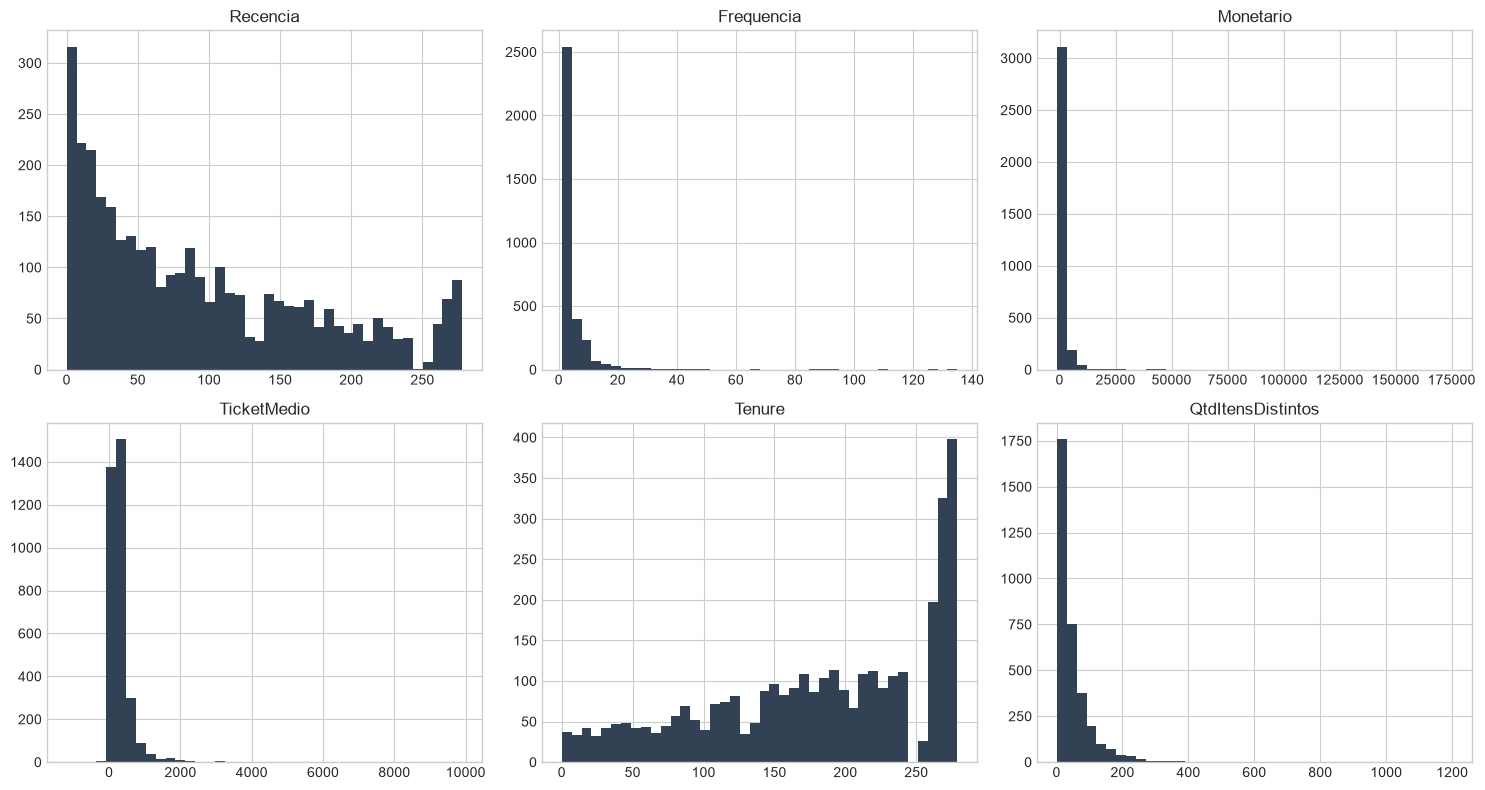

In [10]:
feature_cols = ['Recencia', 'Frequencia', 'Monetario', 'TicketMedio', 'Tenure', 'QtdItensDistintos']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, feature_cols):
    ax.hist(data[col], bins=40, color='#334155')
    ax.set_title(col)
plt.tight_layout()
plt.show()

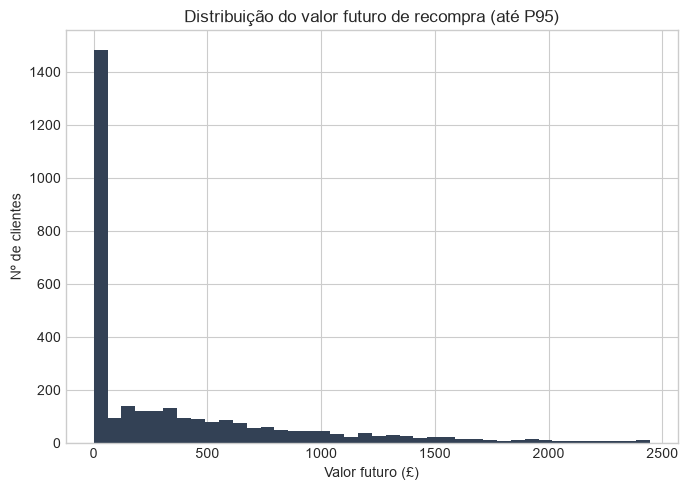

In [11]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(data['ValorFuturo'][data['ValorFuturo'] < data['ValorFuturo'].quantile(0.95)], bins=40, color='#334155')
ax.set_title('Distribuição do valor futuro de recompra (até P95)')
ax.set_xlabel('Valor futuro (£)')
ax.set_ylabel('Nº de clientes')
plt.tight_layout()
plt.show()

## 6. Divisão Treino/Teste

As features e o alvo já estão separados temporalmente, sem sobreposição, então a divisão treino/teste dos clientes pode ser aleatória (80/20). O conjunto de teste não participa de nenhuma etapa de ajuste: nem imputação, nem escala, nem seleção de hiperparâmetro.

In [12]:
X = data[feature_cols].copy()
y = data['ValorFuturo'].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
print(f"Treino: {len(X_train)} clientes | Teste: {len(X_test)} clientes")

Treino: 2701 clientes | Teste: 676 clientes


## 7. Diagnóstico de Multicolinearidade (VIF)

Variáveis RFM tendem a se correlacionar: quem compra com mais frequência tende a gastar mais no total. O VIF (Variance Inflation Factor) mede essa redundância entre preditores, calculado **apenas no treino**.

In [13]:
Xc = X_train.copy()
Xc.insert(0, 'const', 1.0)
vif = pd.DataFrame({
    'feature': feature_cols,
    'VIF': [variance_inflation_factor(Xc.values, i + 1) for i in range(len(feature_cols))]
})
vif

,feature,VIF
0,Recencia,1.413052
1,Frequencia,2.823515
2,Monetario,2.129762
3,TicketMedio,1.612065
4,Tenure,1.391240
5,QtdItensDistintos,2.220381


## 8. Escalonamento

Regressão Linear e Ridge são sensíveis à escala das variáveis, porque os dois modelos se baseiam em gradiente e norma de coeficientes. O código aplica `StandardScaler`, com `fit` **somente no treino** e `transform` no teste, o que evita data leakage.

In [14]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

## 9. Modelo A: Regressão Linear Múltipla

In [15]:
model_a = LinearRegression()
model_a.fit(X_train_s, y_train)
pred_a = model_a.predict(X_test_s)

pd.Series(model_a.coef_, index=feature_cols, name='Coeficiente (padronizado)')

Recencia               70.184167
Frequencia            -57.006438
Monetario            4110.383309
TicketMedio          -471.766283
Tenure               -162.914890
QtdItensDistintos    -110.061433
Name: Coeficiente (padronizado), dtype: float64

## 10. Modelo B: Regressão Ridge (com otimização de hiperparâmetro)

O código escolhe o hiperparâmetro `alpha` (força da regularização L2) via `GridSearchCV`, com validação cruzada de 5 folds **dentro do treino**. O conjunto de teste nunca participa dessa escolha.

In [16]:
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
param_grid = {'alpha': [0.01, 0.1, 1.0, 5.0, 10.0, 50.0, 100.0]}

grid = GridSearchCV(Ridge(random_state=RANDOM_STATE), param_grid, cv=kf, scoring='neg_mean_absolute_error')
grid.fit(X_train_s, y_train)

model_b = grid.best_estimator_
pred_b = model_b.predict(X_test_s)

print("Melhor alpha:", grid.best_params_['alpha'])

Melhor alpha: 100.0


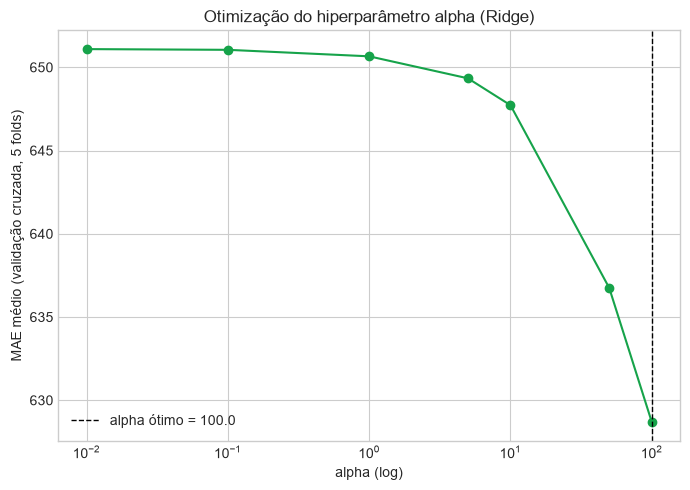

In [17]:
alphas = param_grid['alpha']
mae_cv = -grid.cv_results_['mean_test_score']

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(alphas, mae_cv, marker='o', color='#16a34a')
ax.set_xscale('log')
ax.axvline(grid.best_params_['alpha'], color='k', linestyle='--', linewidth=1, label=f"alpha ótimo = {grid.best_params_['alpha']}")
ax.set_xlabel('alpha (log)')
ax.set_ylabel('MAE médio (validação cruzada, 5 folds)')
ax.set_title('Otimização do hiperparâmetro alpha (Ridge)')
ax.legend()
plt.tight_layout()
plt.show()

## 11. Avaliação e Comparação dos Modelos

Métricas usadas (Aula 5 e 6): **MAE** (erro típico, mesma unidade do alvo), **RMSE** (penaliza erros grandes), **R²** (variância explicada) e **R² ajustado** (penaliza número de preditores).

In [18]:
def metrics(y_true, y_pred, n_features):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    n = len(y_true)
    r2_adj = 1 - (1 - r2) * (n - 1) / (n - n_features - 1)
    return {'MAE': mae, 'RMSE': rmse, 'R²': r2, 'R² ajustado': r2_adj}


tabela_metricas = pd.DataFrame({
    'Modelo A (Linear Múltipla)': metrics(y_test, pred_a, len(feature_cols)),
    'Modelo B (Ridge)': metrics(y_test, pred_b, len(feature_cols)),
}).T
tabela_metricas

,MAE,RMSE,R²,R² ajustado
Modelo A (Linear Múltipla),463.256787,791.002152,0.372320,0.366690
Modelo B (Ridge),444.361806,774.054487,0.398928,0.393538


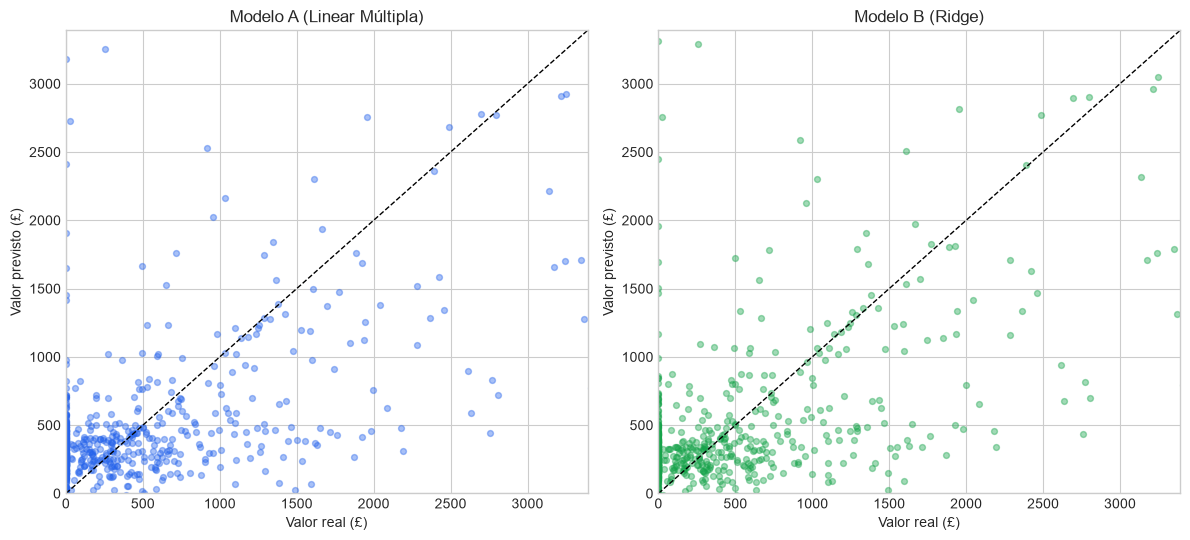

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
for ax, pred, label, color in zip(axes, [pred_a, pred_b], ['Modelo A (Linear Múltipla)', 'Modelo B (Ridge)'], ['#2563eb', '#16a34a']):
    ax.scatter(y_test, pred, alpha=0.4, s=18, color=color)
    lim = y_test.quantile(0.98)
    ax.plot([0, lim], [0, lim], 'k--', linewidth=1)
    ax.set_xlim(0, lim)
    ax.set_ylim(0, lim)
    ax.set_xlabel('Valor real (£)')
    ax.set_ylabel('Valor previsto (£)')
    ax.set_title(label)
plt.tight_layout()
plt.show()

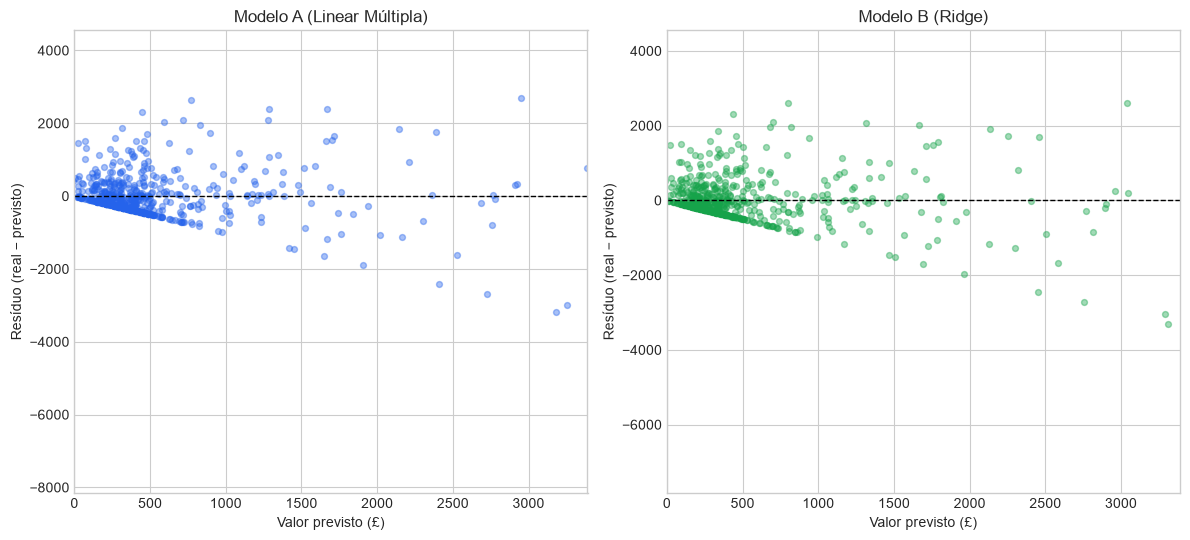

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
for ax, pred, label, color in zip(axes, [pred_a, pred_b], ['Modelo A (Linear Múltipla)', 'Modelo B (Ridge)'], ['#2563eb', '#16a34a']):
    resid = y_test.values - pred
    ax.scatter(pred, resid, alpha=0.4, s=18, color=color)
    ax.axhline(0, color='k', linestyle='--', linewidth=1)
    ax.set_xlim(0, y_test.quantile(0.98))
    ax.set_xlabel('Valor previsto (£)')
    ax.set_ylabel('Resíduo (real − previsto)')
    ax.set_title(label)
plt.tight_layout()
plt.show()

## 12. Análise Crítica

- O **Modelo B (Ridge)** supera o Modelo A em todas as métricas no conjunto de teste: MAE e RMSE menores, R² e R² ajustado maiores. Os VIFs não indicam multicolinearidade severa (todos abaixo de 3); o ganho vem principalmente da regularização, que reduz a variância causada pela cauda pesada da feature `Monetario` (poucos clientes com gasto histórico muito acima da mediana).
- Os gráficos de resíduos não mostram funil ou curva acentuada. Os dois modelos erram mais para clientes de alto valor futuro, um resultado esperado: o comportamento de recompra de clientes extremos é mais difícil de prever com apenas 6 features RFM.
- O R² entre 0,37 e 0,40 mostra que os modelos capturam parte relevante do padrão de recompra, mas deixam boa parte da variância sem explicar. Isso é plausível para o problema, já que o comportamento de compra futuro tem componente aleatório e externo que o RFM sozinho não capta.
- Próximos passos, quando o professor apresentar o conteúdo em aula: comparar os resultados contra modelos não lineares (árvore ou floresta aleatória) e avaliar clientes de alto potencial como um problema de classificação complementar.

## 13. Referências

- Dataset: Chen, D. (2015). *Online Retail*. UCI Machine Learning Repository. https://doi.org/10.24432/C5BW33
- Material de aula: Aulas 2 a 6, disciplina de Machine Learning (Prof. Rodrigo Ramos Silva).